In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import gridspec
import MATS

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")


HAPI version: 1.2.2.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

You are using the 'self' term, consider explicitly labeling the broadener (ie in an oxygen spectra use 'O2' instead of 'self').  This may avoid confusion in multiple species fits. For single species fits it should not matter.
Double check that you did not include the equivalent of the self term explicitly (ie in an oxygen spectra having both 'O2' and 'self').


C:\Users\ema3\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3420: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
C:\Users\ema3\Anaconda3\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


You are using the 'self' term, consider explicitly labeling the broadener (ie in an oxygen spectra use 'O2' instead of 'self').  This may avoid confusion in multiple species fits. For single species fits it should not matter.
Double check that you did not include the equivalent of the self term explicitly (ie in an oxygen spectra having both 'O2' and 'self').
You are using the 'self' term, consider explicitly labeling the broadener (ie in an oxygen spectra use 'O2' instead of 'self').  This may avoid confusion in multiple species fits. For single species fits it should not matter.
Double check that you did not include the equivalent of the self term explicitly (ie in an oxygen spectra having both 'O2' and 'self').


(4820.0, 4910.0)

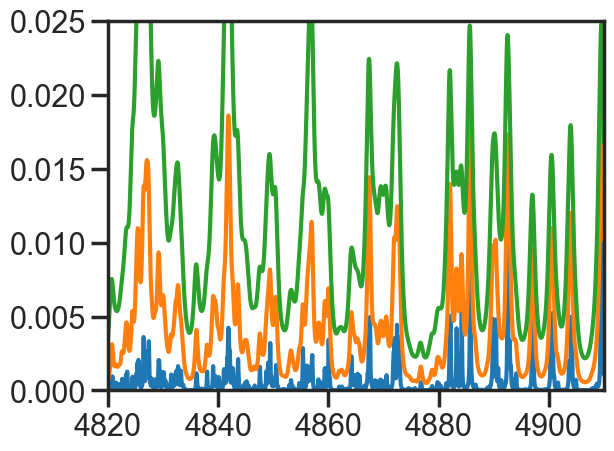

In [14]:
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-24 #intensities must be above this value for the line to be fit
order_baseline_fit = 1
wavenumbers = np.arange(13159.61331, 13165.78895, 0.005)
baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order

sample_molefraction_1 = {7 :0.0025142}
sample_molefraction_2 = {7 :0.01949}
sample_molefraction_3 = {7 :0.20868}
sample_molefraction_4 = {7 :1}

#from MATS.linelistdata import linelistdata
#PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']
#PARAM_LINELIST['SD_gamma_air'] = 0


PARAM_LINELIST = pd.read_csv('Methane_Linelist.csv')


spec_1 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = np.arange(4820, 4910, 0.01),
                    baseline_terms = baseline_terms, temperature = 22.85, 
                    pressure = 760, molefraction = {6:1}, diluent = 'self',  
                    wing_wavenumbers  = 25,  wing_method = 'wing_wavenumbers', TIPS = MATS.hapi.PYTIPS2017, 
                    low_OD_regime = False, transmittance_space = False, pathlength = 300)
spec_2 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = np.arange(4820, 4910, 0.01),
                    baseline_terms = baseline_terms, temperature = 350-273.15, 
                    pressure = 760*5, molefraction = {6:1}, diluent = 'self',  
                    wing_wavenumbers  = 25,  wing_method = 'wing_wavenumbers', TIPS = MATS.hapi.PYTIPS2017, 
                    low_OD_regime = False, transmittance_space = False, pathlength = 300)
spec_3 =  MATS.simulate_spectrum(PARAM_LINELIST, wavenumbers = np.arange(4820, 4910, 0.01),
                    baseline_terms = baseline_terms, temperature = 400-273.15, 
                    pressure = 760*10, molefraction = {6:1}, diluent = 'self',  
                    wing_wavenumbers  = 25,  wing_method = 'wing_wavenumbers', TIPS = MATS.hapi.PYTIPS2017, 
                    low_OD_regime = False, transmittance_space = False, pathlength = 300)


plt.plot(spec_1.wavenumber, spec_1.alpha)
plt.plot(spec_2.wavenumber, spec_2.alpha)
plt.plot(spec_3.wavenumber, spec_3.alpha)
plt.ylim(0, 0.025)
plt.xlim(4820, 4910)

#PARAM_LINELIST['nu'].min()
